## 1.Import Libraries

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,silhouette_score,calinski_harabasz_score

## 2.Data Collection

In [79]:
college_data = pd.read_csv("college_list.csv")
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


## 3.Data Understanding

In [80]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


In [6]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [7]:
college_data.dtypes

College_Name              object
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object

In [9]:
college_data["College_Name"].unique()

array(['Indian Institute of Technology Madras - Campus 1',
       'National Institute of Technology Trichy - Campus 1',
       'Anna University Chennai - Campus 1',
       'PSG College of Technology - Campus 1',
       'Coimbatore Institute of Technology - Campus 1',
       'Government College of Technology Coimbatore - Campus 1',
       'SSN College of Engineering - Campus 1',
       'SRM Institute of Science and Technology - Campus 1',
       'VIT Vellore - Campus 1', 'SASTRA University - Campus 1',
       'Sri Sairam Engineering College - Campus 1',
       'Velammal Engineering College - Campus 1',
       'Rajalakshmi Engineering College - Campus 1',
       'St Josephs College of Engineering - Campus 1',
       'Kumaraguru College of Technology - Campus 1',
       'Thiagarajar College of Engineering - Campus 1',
       'Bannari Amman Institute of Technology - Campus 1',
       'Sri Krishna College of Engineering and Technology - Campus 1',
       'Sona College of Technology - Campus

## 4.Data Preparation

### 4.1. Remove Unnecessary Column

In [81]:
X = college_data.drop("College_Name",axis=1)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


### 4.2 Applying Data Transformation Technique

In [82]:
from sklearn.preprocessing import StandardScaler
st_scaler = StandardScaler()
scaled_X = st_scaler.fit_transform(X)
scaled_X = pd.DataFrame(scaled_X)
scaled_X

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [83]:
scaled_X.mean().round(4),scaled_X.std().round(4)

(0    0.0
 1    0.0
 2   -0.0
 3    0.0
 4   -0.0
 dtype: float64,
 0    1.001
 1    1.001
 2    1.001
 3    1.001
 4    1.001
 dtype: float64)

## 5.Model Building

In [84]:
new_clusters = KMeans(n_clusters=3,random_state=12)
new_clusters.fit(scaled_X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [85]:
new_clusters = new_clusters.fit_predict(scaled_X)
new_clusters

array([2, 0, 0, 0, 2, 1, 1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1, 2,
       2, 0, 1, 1, 2, 0, 0, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 1, 0,
       1, 0, 2, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 1, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 1, 2, 2,
       0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 1, 0, 0, 2, 2, 0, 0, 2, 0, 0,
       0, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 0, 1, 2, 2, 1, 2, 2, 2, 0, 2, 0, 2,
       2, 2, 1, 1, 1, 2, 1, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 2, 0, 1,
       1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 1, 1, 0, 2, 0, 1, 1, 1, 2, 2, 0, 1,
       1, 0, 2, 1, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 0, 1, 1, 1, 2, 2,
       1, 2, 0, 0, 1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2,

In [73]:
# Silhouette Score
score = silhouette_score(scaled_X, new_clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.14911504231676975


In [76]:
#Calinski harbasz Score
score = calinski_harabasz_score(scaled_X, new_clusters)
print("Calinski-Harabasz Score:", score)

Calinski-Harabasz Score: 86.56192506107278


### Clustering is done.Now lets put this back to the original dataset for further data mining operation

In [28]:
college_data["College_Level"] = new_clusters

college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,2
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,2
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,2
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,2


In [29]:
X["College_Level"]= new_clusters

In [37]:
X.groupby("College_Level").agg(["mean"])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
College_Level,,,,,
0,23.425676,116224.283784,70.040541,6.787973,7.554054
1,20.347305,143690.473054,74.622754,7.131078,3.862275
2,11.767568,152347.848649,63.091892,7.028919,6.621622


In [38]:
X.groupby("College_Level").agg(["min","max"])

Student_Faculty_Ratio     Annual_Fees_INR          ... Average_Package_LPA        Infrastructure_Score    
                                min max             min     max  ...                 min    max                  min max
College_Level                                                    ...                                                    
0                                14  29           30404  249536  ...                2.00  11.99                    5   9
1                                 8  29           31605  248803  ...                2.01  11.96                    3   6
2                                 8  22           31015  249930  ...                2.01  11.91                    3   9

[3 rows x 10 columns]

In [40]:
new_labels = {0:"Best Colleges",
              1:"Mid Level Colleges",
              2:"Low Level / Emerging Colleges"}

X["Category"] = X["College_Level"].map(new_labels)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Low Level / Emerging Colleges
1,27,115999,67,3.07,7,0,Best Colleges
2,22,47955,50,3.40,9,0,Best Colleges
3,18,67841,43,4.64,8,0,Best Colleges
4,15,100640,54,4.66,9,2,Low Level / Emerging Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,2,Low Level / Emerging Colleges
496,12,39111,76,3.62,7,2,Low Level / Emerging Colleges
497,16,199182,64,3.88,3,1,Mid Level Colleges
498,10,46389,77,9.31,6,2,Low Level / Emerging Colleges


## Now it's time for supervised learning

In [47]:
input_data = X.drop(["College_Level","Category"],axis=1)
output_data = X["College_Level"]

X_train, X_test, y_train, y_test = train_test_split(input_data,output_data,test_size=0.20,shuffle = True)

In [49]:
X_train.shape,X_test.shape

((400, 5), (100, 5))

In [61]:
dt_model = DecisionTreeClassifier(max_depth = 7)
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
y_pred_test = dt_model.predict(X_test)

print("Accuracy Score:",accuracy_score(y_test,y_pred_test))

Accuracy Score: 0.89


## How to find the optimal Number fo Clusters?
The K-Means algorithm aims to choose centroids that minimise the inertia or within clusters sum of squares criteria

In [64]:
wcss=[]

for i in range(1,11):
    kmeans = KMeans(n_clusters = i,random_state=123)
    kmeans.fit(scaled_X)
    wcss.append(kmeans.inertia_)

wcss

[2499.9999999999995,
 2116.146420072567,
 1842.6441404313482,
 1645.3145628422574,
 1467.1142331378942,
 1379.1359845255677,
 1289.8223290666117,
 1229.9769681245727,
 1160.1076312943665,
 1090.5733088472773]

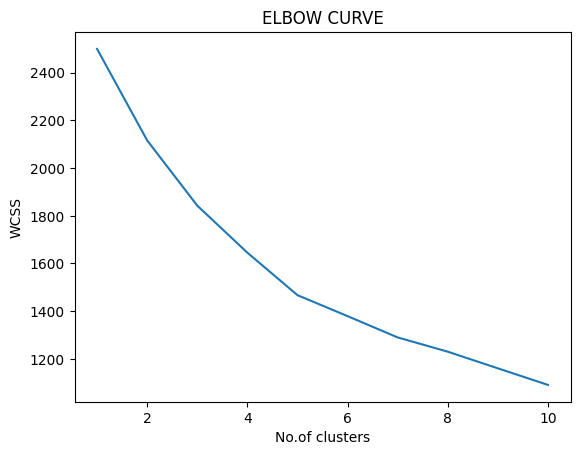

In [65]:
plt.plot(range(1,11),wcss)
plt.title("ELBOW CURVE")
plt.xlabel("No.of clusters")
plt.ylabel("WCSS")
plt.show()